# Thông tin sinh viên

*   MSSV: xxxxxxx
*   Họ và tên: xxxxxxx



#Bài tập 5: Phân loại ảnh sử dụng mạng tích chập CNN

#Kết nối/ Mount đến Google Drive

In [209]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Khai báo thư viện

In [210]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD

from sklearn.model_selection import train_test_split


# Đọc dữ liệu

In [211]:
# Hàm đọc dữ liệu từ thư mục folder
def load_images_from_folder(folder, img_rows, img_cols):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))

    for label, class_name in enumerate(class_names):
        class_folder = os.path.join(folder, class_name)
        if os.path.isdir(class_folder):
            for filename in os.listdir(class_folder):
                img_path = os.path.join(class_folder, filename)
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.resize(img, (img_rows, img_cols))
                    images.append(img)
                    labels.append(label)

    return images, labels, class_names


In [212]:
# Đọc dữ liệu từ thư mục Dataset
train_folder  = "/content/drive/MyDrive/CS231/Dataset/HoaVietNam/train"
test_folder   = "/content/drive/MyDrive/CS231/Dataset/HoaVietNam/test"

img_rows, img_cols = 128, 128


training_images, training_labels, class_names = load_images_from_folder(train_folder, img_rows, img_cols)
test_images, test_labels, _ = load_images_from_folder(test_folder, img_rows, img_cols)

##  Chia tập dữ liệu

In [213]:
train_images, validation_images, train_labels, validation_labels = train_test_split (training_images, training_labels, test_size=1/3, train_size=2/3, random_state=42)

## Xử lý dữ liệu

In [214]:
train_images = np.array(train_images)
validation_images = np.array(validation_images)
test_images = np.array(test_images)

# Chuyển đổi miền giá trị
train_images = train_images.reshape((len(train_images), img_rows, img_cols, 3)).astype ('float32') / 255
validation_images = validation_images.reshape((len(validation_images), img_rows, img_cols, 3)).astype('float32') / 255
test_images = test_images.reshape((len(test_images), img_rows, img_cols, 3)).astype('float32') / 255



train_labels = to_categorical(train_labels)
validation_labels = to_categorical(validation_labels)
test_labels = to_categorical(test_labels)

In [215]:
print(f"Kích thước tập train: {train_images.shape}, {train_labels.shape}")
print(f"Kích thước tập validation: {validation_images.shape}, {validation_labels.shape}")
print(f"Kích thước tập test: {test_images.shape}, {test_labels.shape}")

Kích thước tập train: (100, 128, 128, 3), (100, 5)
Kích thước tập validation: (50, 128, 128, 3), (50, 5)
Kích thước tập test: (50, 128, 128, 3), (50, 5)


In [216]:
validation_labels

array([[0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1.

## Khai báo mạng CNN

In [217]:
model = models.Sequential()

model.add(layers.Conv2D(6, (3, 3), activation='relu', input_shape=(img_rows, img_cols, 3),padding='same'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(16, (3, 3), activation='relu',padding='same'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(120, activation='relu'))
model.add(layers.Dense(84, activation='relu'))
model.add(layers.Dense(5, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [218]:
# Compile the model
opt = Adam(learning_rate=0.00001)
model.compile(optimizer= opt, loss='categorical_crossentropy', metrics=['accuracy'])


In [219]:
# Display model summary
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 64, 64, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 16)     │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 120)            │     1,966,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 5)              │           425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,977,837 (7.54 MB)

 Trainable params: 1,977,837 (7.54 MB)

 Non-trainable params: 0 (0.00 B)

# Yêu cầu 1
* Thực hiện huấn luyện mô hình
* Hiển thị biểu đồ cho biết Độ chính xác và loss trong quá trình huấn luyện

## Huấn luyện mô hình

In [220]:
# Train the model with validation data
history = model.fit(train_images, train_labels, epochs=15, batch_size=8, validation_data=(validation_images, validation_labels))


Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.2164 - loss: 1.5839 - val_accuracy: 0.2200 - val_loss: 1.6070
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.1833 - loss: 1.6098 - val_accuracy: 0.2200 - val_loss: 1.5963
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.2470 - loss: 1.5437 - val_accuracy: 0.2400 - val_loss: 1.5869
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.2888 - loss: 1.5522 - val_accuracy: 0.3200 - val_loss: 1.5672
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.4271 - loss: 1.5102 - val_accuracy: 0.3800 - val_loss: 1.5641
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - accuracy: 0.4875 - loss: 1.5054 - val_accuracy: 0.4200 - val_loss: 1.5609
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - accuracy: 0.4665 - loss: 1.5017 - val_accuracy: 0.4400 - val_loss: 1.5468
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.4749 - loss: 1.4796 - val_accuracy: 0.36

## Thông tin quá trình huấn luyện

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


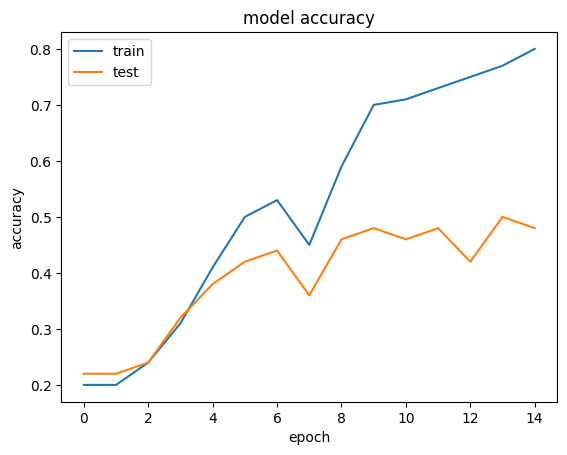

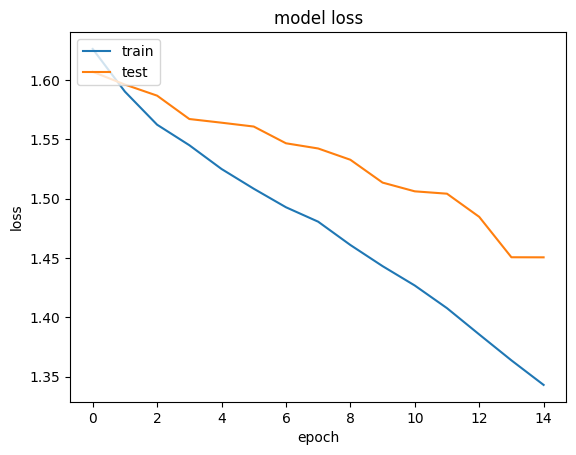

In [221]:
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# Yêu cầu 2
* Đánh giá kết quả của mô hình trên tập Test
* Sử dụng hàm classification_report để in ra kết quả phân loại của hai mô hình.


#Đánh giá kết quả

In [222]:
# Testing the model on test data
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=2)
print(f"Test Accuracy: {test_accuracy}")
print(f"Test Loss: {test_loss}")

2/2 - 0s - 103ms/step - accuracy: 0.5800 - loss: 1.4258
Test Accuracy: 0.5799999833106995
Test Loss: 1.4257879257202148


In [223]:
train_labels.shape

(100, 5)

## In ra kết quả phân loại

In [224]:
# Predicting labels for test images
predicted_labels = np.argmax(model.predict(test_images), axis=-1)
# Display classification report
print("Classification Report:\n", classification_report(np.argmax(test_labels, axis=-1), predicted_labels))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.38      0.80      0.52        10
           2       0.67      0.60      0.63        10
           3       0.56      0.50      0.53        10
           4       1.00      0.20      0.33        10

    accuracy                           0.58        50
   macro avg       0.70      0.58      0.57        50
weighted avg       0.70      0.58      0.57        50

